<a href="https://colab.research.google.com/github/jmoralespineda/TEORIA_DE_SE-ALES/blob/main/TALLERES.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## TALLER ESPECTRO DE POTENCIA - EXTRACLASE  19/09/2025
# Julian David Moralesa Pineda

#🔹Generar realizaciones y calcular PSD

In [1]:
import torch
import matplotlib.pyplot as plt

# Parámetros
fs = 1024        # frecuencia de muestreo
N = 1024         # número de muestras
t = torch.arange(N) / fs
f1, f2 = 50, 120  # frecuencias base
f0 = 10          # fundamental del tren de pulsos
num_harmonics = 20  # armónicos de onda cuadrada
M = 30           # número de realizaciones


In [2]:
# Listas para almacenar PSDs
psd_list, norms = [], []

for _ in range(M):
    # Señal aleatoria base
    signal = torch.sin(2 * torch.pi * f1 * t) + 0.5*torch.sin(2 * torch.pi * f2 * t)
    signal += 0.3*torch.randn(N)

    # Tren de pulsos cuadrado con armónicos impares
    square_wave = torch.zeros_like(t)
    for k in range(1, 2*num_harmonics, 2):
        square_wave += (1/k) * torch.sin(2 * torch.pi * k * f0 * t)
    square_wave *= 4/torch.pi

    # Señal final
    final_signal = signal + square_wave

    # FFT
    fft_signal = torch.fft.fft(final_signal)

    # Power Spectral Density (PSD)
    psd = (1/N) * torch.abs(fft_signal)**2
    psd_list.append(psd)

    # Norma espectral (energía total = integral PSD)
    norms.append(psd.sum())

# Convertir a tensores
psd_list = torch.stack(psd_list)
norms = torch.tensor(norms)


#🔹 Promedios y desviaciones

In [3]:
# Estadísticos de aleatoriedad
mean_psd = psd_list.mean(dim=0)
std_psd = psd_list.std(dim=0)
mean_norm = norms.mean()
std_norm = norms.std()

# Frecuencias asociadas
freqs = torch.fft.fftfreq(N, d=1/fs)


#🔹Grafica de resultados

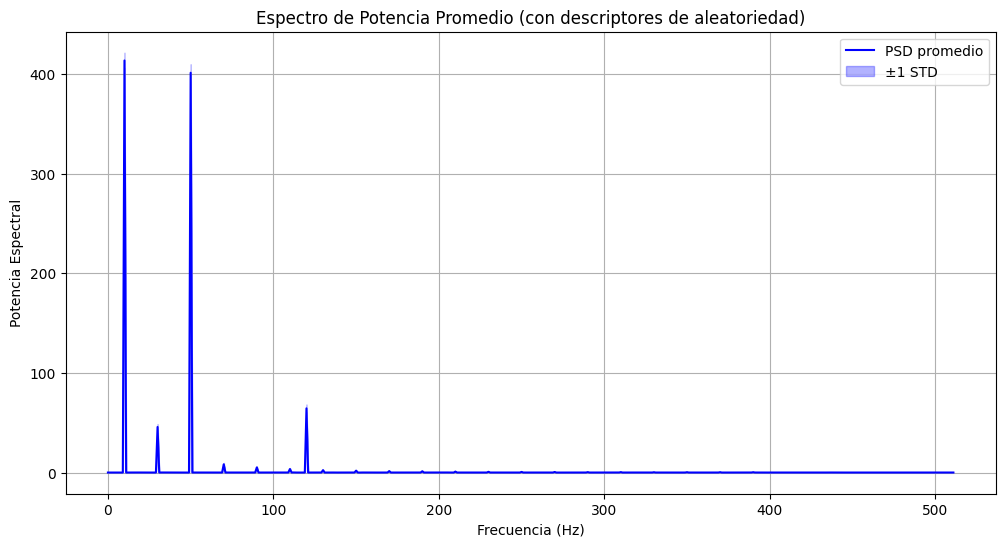

Norma promedio del espectro de potencia: 2001.8861
Desviación estándar de la norma: 22.4183


In [4]:
plt.figure(figsize=(12,6))

plt.plot(freqs[:N//2], mean_psd[:N//2], label="PSD promedio", color="blue")
plt.fill_between(freqs[:N//2],
                 (mean_psd - std_psd)[:N//2],
                 (mean_psd + std_psd)[:N//2],
                 color="blue", alpha=0.3, label="±1 STD")

plt.title("Espectro de Potencia Promedio (con descriptores de aleatoriedad)")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Potencia Espectral")
plt.legend()
plt.grid()
plt.show()

print(f"Norma promedio del espectro de potencia: {mean_norm:.4f}")
print(f"Desviación estándar de la norma: {std_norm:.4f}")


#🔹One realization — PSD

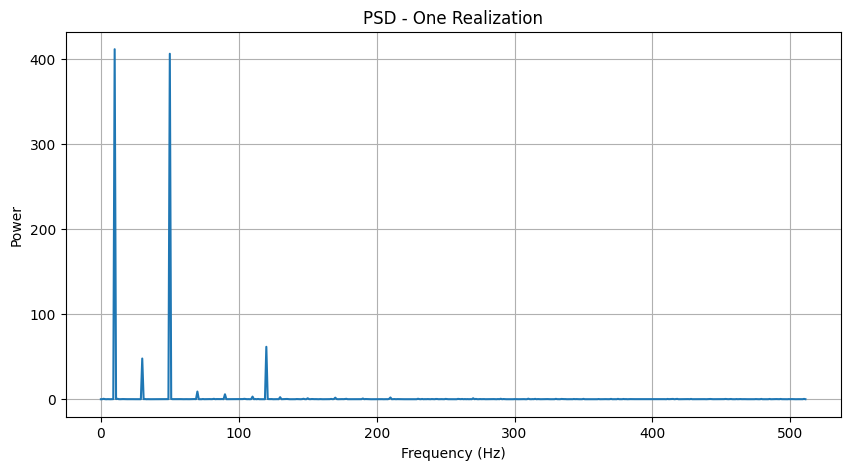

In [5]:
import torch
import matplotlib.pyplot as plt

# Parameters
fs = 1024       # sampling frequency
N = 1024        # samples
t = torch.arange(N) / fs
f1, f2 = 50, 120
f0 = 10         # square wave fundamental
num_harmonics = 20

# ----- One realization -----
# Base signal with noise
signal = torch.sin(2*torch.pi*f1*t) + 0.5*torch.sin(2*torch.pi*f2*t)
signal += 0.3*torch.randn(N)

# Add square wave via Fourier series
square_wave = torch.zeros_like(t)
for k in range(1, 2*num_harmonics, 2):
    square_wave += (1/k)*torch.sin(2*torch.pi*k*f0*t)
square_wave *= 4/torch.pi

final_signal = signal + square_wave

# FFT
fft_signal = torch.fft.fft(final_signal)
psd = (1/N) * torch.abs(fft_signal)**2
freqs = torch.fft.fftfreq(N, d=1/fs)

# Plot PSD for one realization
plt.figure(figsize=(10,5))
plt.plot(freqs[:N//2], psd[:N//2])
plt.title("PSD - One Realization")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.grid(True)
plt.show()


#🔹Multiple realizations — PSD with randomness descriptors

In [6]:
M = 30   # number of realizations
psd_list, norms = [], []

for _ in range(M):
    # Random signal
    signal = torch.sin(2*torch.pi*f1*t) + 0.5*torch.sin(2*torch.pi*f2*t)
    signal += 0.3*torch.randn(N)

    # Add square wave
    square_wave = torch.zeros_like(t)
    for k in range(1, 2*num_harmonics, 2):
        square_wave += (1/k)*torch.sin(2*torch.pi*k*f0*t)
    square_wave *= 4/torch.pi

    final_signal = signal + square_wave

    # FFT -> PSD
    fft_signal = torch.fft.fft(final_signal)
    psd = (1/N) * torch.abs(fft_signal)**2

    psd_list.append(psd)
    norms.append(psd.sum())   # energy via Parseval

# Stack results
psd_list = torch.stack(psd_list)
norms = torch.tensor(norms)

# Descriptors
mean_psd = psd_list.mean(dim=0)
std_psd  = psd_list.std(dim=0)
mean_norm = norms.mean()
std_norm = norms.std()


#🔹Plot with descriptors

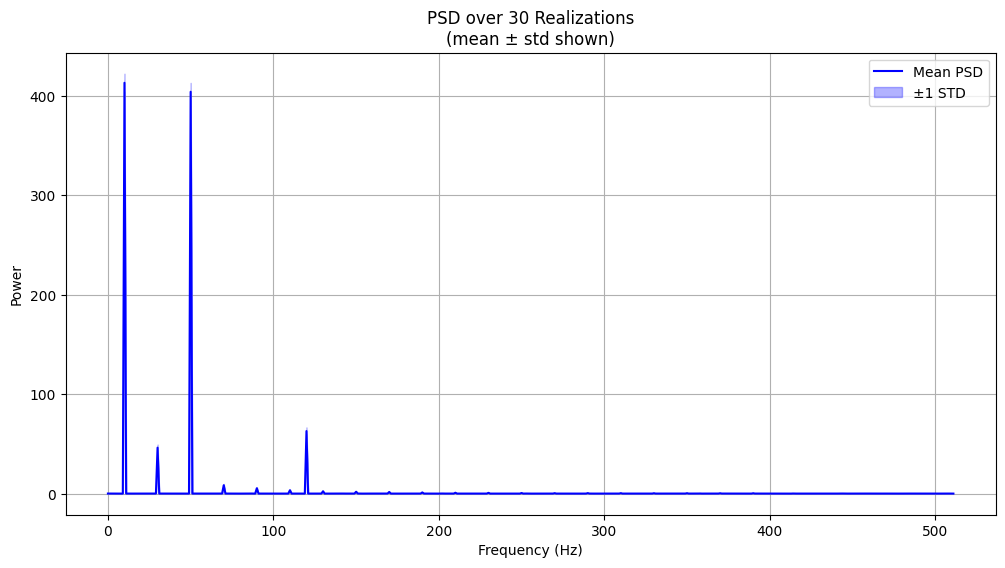

Mean spectral norm: 2002.5038
STD of spectral norm: 27.5622


In [7]:
plt.figure(figsize=(12,6))
plt.plot(freqs[:N//2], mean_psd[:N//2], label="Mean PSD", color="blue")
plt.fill_between(freqs[:N//2],
                 (mean_psd-std_psd)[:N//2],
                 (mean_psd+std_psd)[:N//2],
                 color="blue", alpha=0.3, label="±1 STD")
plt.title(f"PSD over {M} Realizations\n(mean ± std shown)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.legend()
plt.grid(True)
plt.show()

print(f"Mean spectral norm: {mean_norm:.4f}")
print(f"STD of spectral norm: {std_norm:.4f}")


## TALLER DE CORRELACION REALIZADO EN CLASE 19/09/2025

🔹 Celda 1: Importar librerías y definir parámetros

In [ ]:
import torch
import matplotlib.pyplot as plt

# Parámetros
fs = 1024        # frecuencia de muestreo (Hz)
N = 1024         # número de muestras
t = torch.arange(N) / fs
f1, f2 = 50, 120  # frecuencias de la señal


🔹 Celda 2: Generar una señal y aplicar FFT

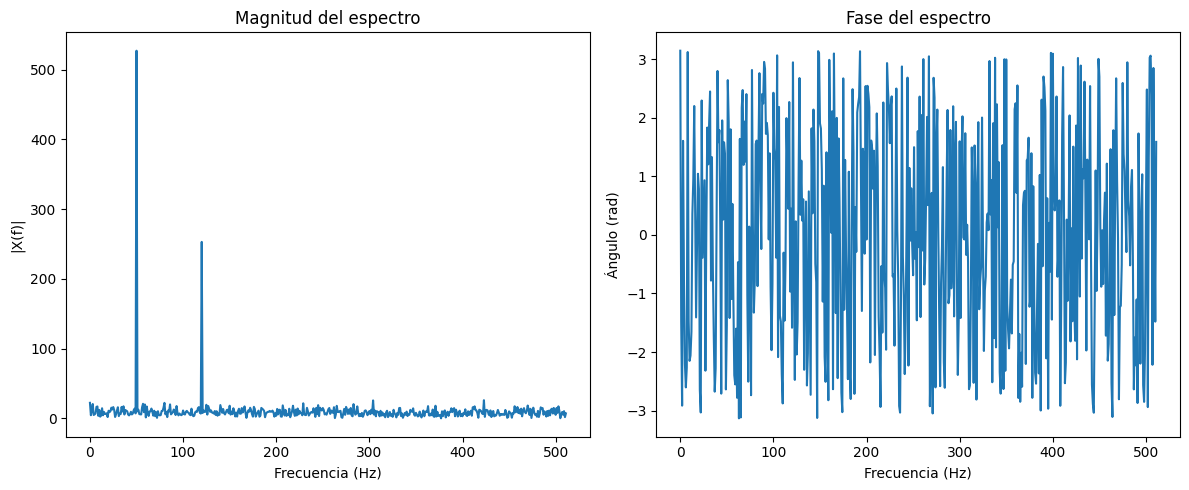

In [ ]:
# Señal determinística + ruido gaussiano
signal = torch.sin(2 * torch.pi * f1 * t) + 0.5*torch.sin(2 * torch.pi * f2 * t)
signal += 0.3*torch.randn(N)  # ruido

# FFT
fft_signal = torch.fft.fft(signal)

# Magnitud y fase
magnitude = torch.abs(fft_signal)
phase = torch.angle(fft_signal)

# Frecuencias asociadas
freqs = torch.fft.fftfreq(N, d=1/fs)

# Graficar
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(freqs[:N//2], magnitude[:N//2])
plt.title("Magnitud del espectro")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("|X(f)|")

plt.subplot(1,2,2)
plt.plot(freqs[:N//2], phase[:N//2])
plt.title("Fase del espectro")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Ángulo (rad)")

plt.tight_layout()
plt.show()


🔹 Celda 3: Epectro promedio

*   Elemento de lista
*   Elemento de lista



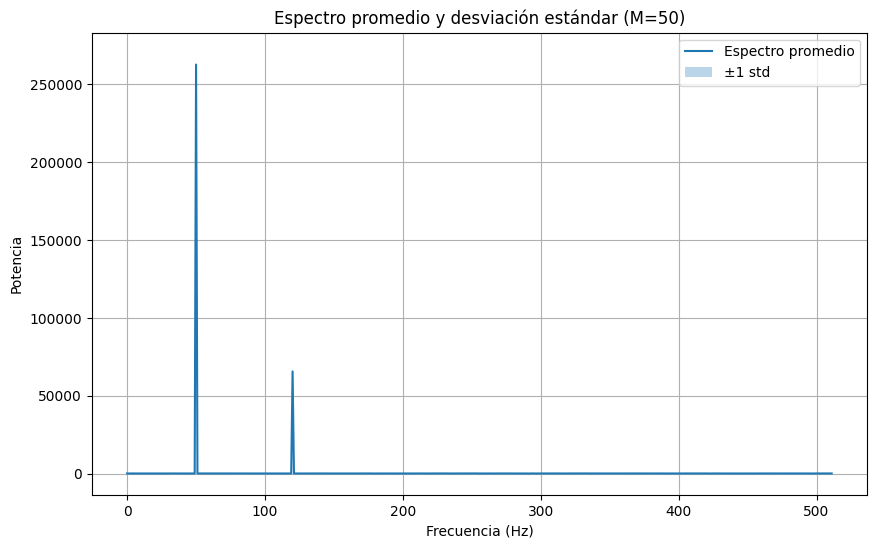

In [ ]:
M = 50  # número de realizaciones
spectra = []

for _ in range(M):
    sig = torch.sin(2 * torch.pi * f1 * t) + 0.5*torch.sin(2 * torch.pi * f2 * t)
    sig += 0.3*torch.randn(N)
    fft_sig = torch.fft.fft(sig)
    spectra.append(torch.abs(fft_sig[:N//2])**2)  # potencia espectral

spectra = torch.stack(spectra)

# Promedio y desviación estándar
mean_spectrum = spectra.mean(dim=0)
std_spectrum = spectra.std(dim=0)

# Graficar espectro promedio con banda de error
plt.figure(figsize=(10,6))
plt.plot(freqs[:N//2], mean_spectrum, label="Espectro promedio")
plt.fill_between(freqs[:N//2],
                 mean_spectrum-std_spectrum,
                 mean_spectrum+std_spectrum,
                 alpha=0.3, label="±1 std")
plt.title("Espectro promedio y desviación estándar (M=50)")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Potencia")
plt.legend()
plt.grid()
plt.show()


🔹 Celda 4: Para una realizacion

In [ ]:
# Señal determinística con ruido
signal = torch.sin(2 * torch.pi * f1 * t) + 0.5*torch.sin(2 * torch.pi * f2 * t)
signal += 0.3*torch.randn(N)

# FFT
fft_signal = torch.fft.fft(signal)

# Descriptores
magnitude = torch.abs(fft_signal)
phase = torch.angle(fft_signal)
real_part = fft_signal.real
imag_part = fft_signal.imag

# Frecuencias
freqs = torch.fft.fftfreq(N, d=1/fs)


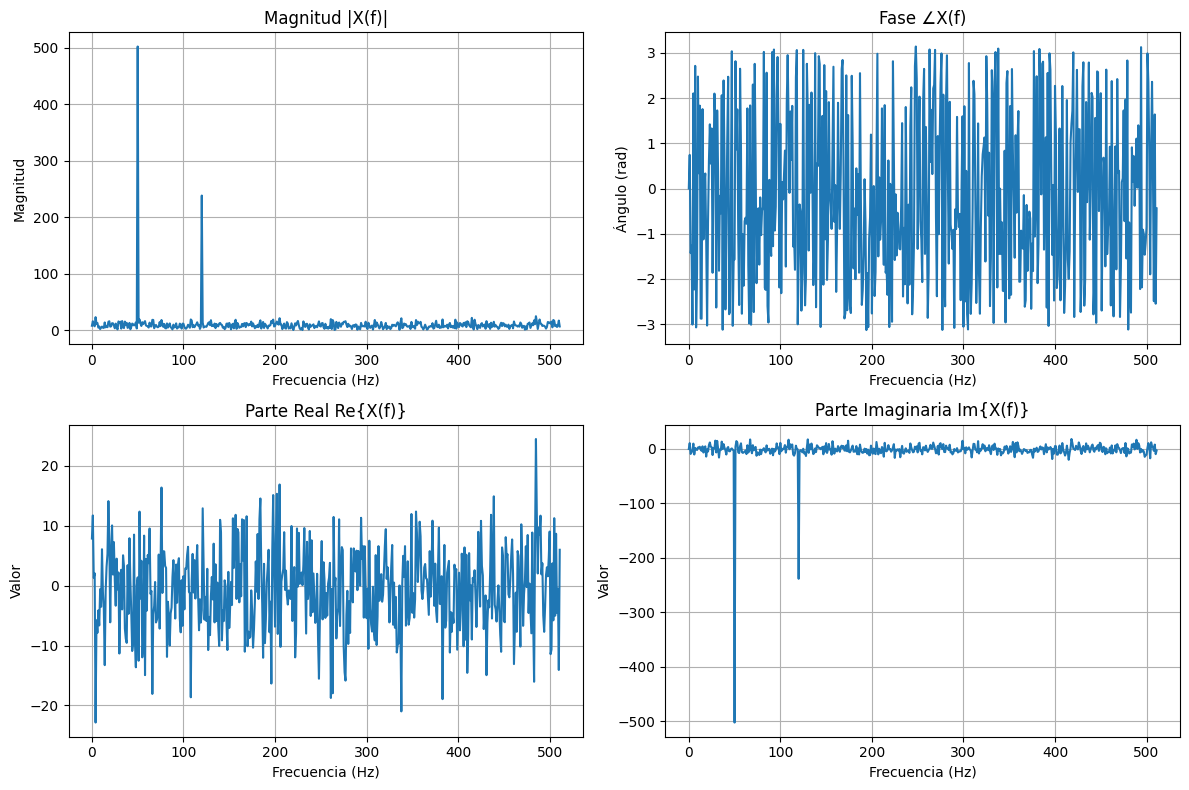

In [ ]:
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.plot(freqs[:N//2], magnitude[:N//2])
plt.title("Magnitud |X(f)|")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Magnitud")
plt.grid()

plt.subplot(2,2,2)
plt.plot(freqs[:N//2], phase[:N//2])
plt.title("Fase ∠X(f)")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Ángulo (rad)")
plt.grid()

plt.subplot(2,2,3)
plt.plot(freqs[:N//2], real_part[:N//2])
plt.title("Parte Real Re{X(f)}")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Valor")
plt.grid()

plt.subplot(2,2,4)
plt.plot(freqs[:N//2], imag_part[:N//2])
plt.title("Parte Imaginaria Im{X(f)}")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Valor")
plt.grid()

plt.tight_layout()
plt.show()


🔹 Celda 5: Para multiples realizaciones

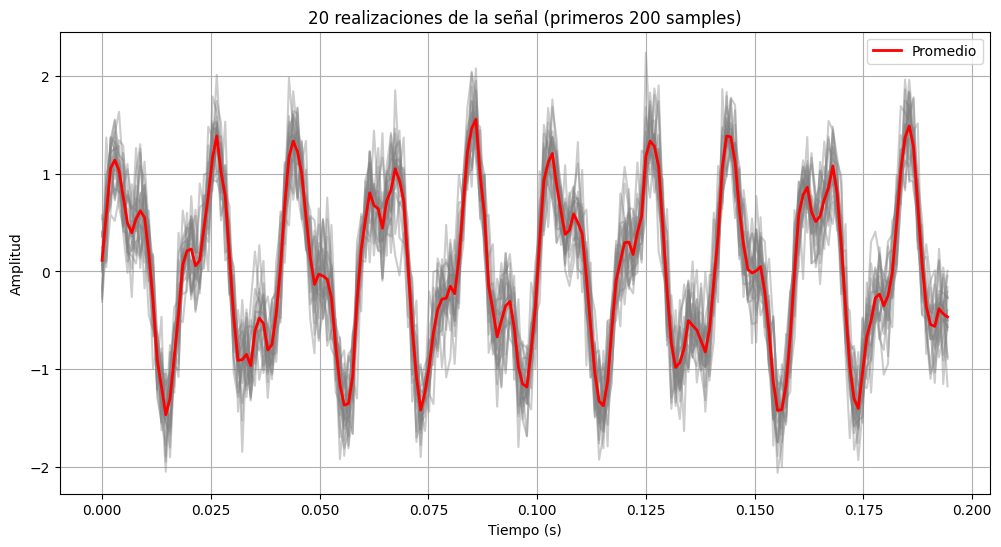

In [ ]:
import torch
import matplotlib.pyplot as plt

# Parámetros
fs = 1024        # frecuencia de muestreo
N = 1024         # número de muestras
t = torch.arange(N) / fs
f1, f2 = 50, 120 # frecuencias de la señal
M = 20           # número de realizaciones a graficar

# Guardar realizaciones
realizations = []

for _ in range(M):
    signal = torch.sin(2 * torch.pi * f1 * t) + 0.5*torch.sin(2 * torch.pi * f2 * t)
    signal += 0.3*torch.randn(N)
    realizations.append(signal)

realizations = torch.stack(realizations)

# Promedio temporal entre realizaciones
mean_signal = realizations.mean(dim=0)

# Graficar
plt.figure(figsize=(12,6))
for r in realizations:
    plt.plot(t[:200], r[:200], color="gray", alpha=0.4)  # primeras 200 muestras
plt.plot(t[:200], mean_signal[:200], color="red", linewidth=2, label="Promedio")
plt.title(f"{M} realizaciones de la señal (primeros 200 samples)")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# Espectros para múltiples realizaciones
magnitudes, phases, reals, imags, norms = [], [], [], [], []

for _ in range(M):
    # Señal con ruido
    signal = torch.sin(2 * torch.pi * f1 * t) + 0.5*torch.sin(2 * torch.pi * f2 * t)
    signal += 0.3*torch.randn(N)

    # FFT
    fft_signal = torch.fft.fft(signal)

    # Descriptores
    magnitudes.append(torch.abs(fft_signal))
    phases.append(torch.angle(fft_signal))
    reals.append(fft_signal.real)
    imags.append(fft_signal.imag)

    # Norma (2-norm del espectro)
    norms.append(torch.norm(fft_signal))

# Convertir a tensores
magnitudes = torch.stack(magnitudes)
phases = torch.stack(phases)
reals = torch.stack(reals)
imags = torch.stack(imags)
norms = torch.tensor(norms)


# Calculo de promedios

In [ ]:
mean_magnitude = magnitudes.mean(dim=0)
mean_phase = phases.mean(dim=0)
mean_real = reals.mean(dim=0)
mean_imag = imags.mean(dim=0)
mean_norm = norms.mean()


# Graficar promedios de espectros

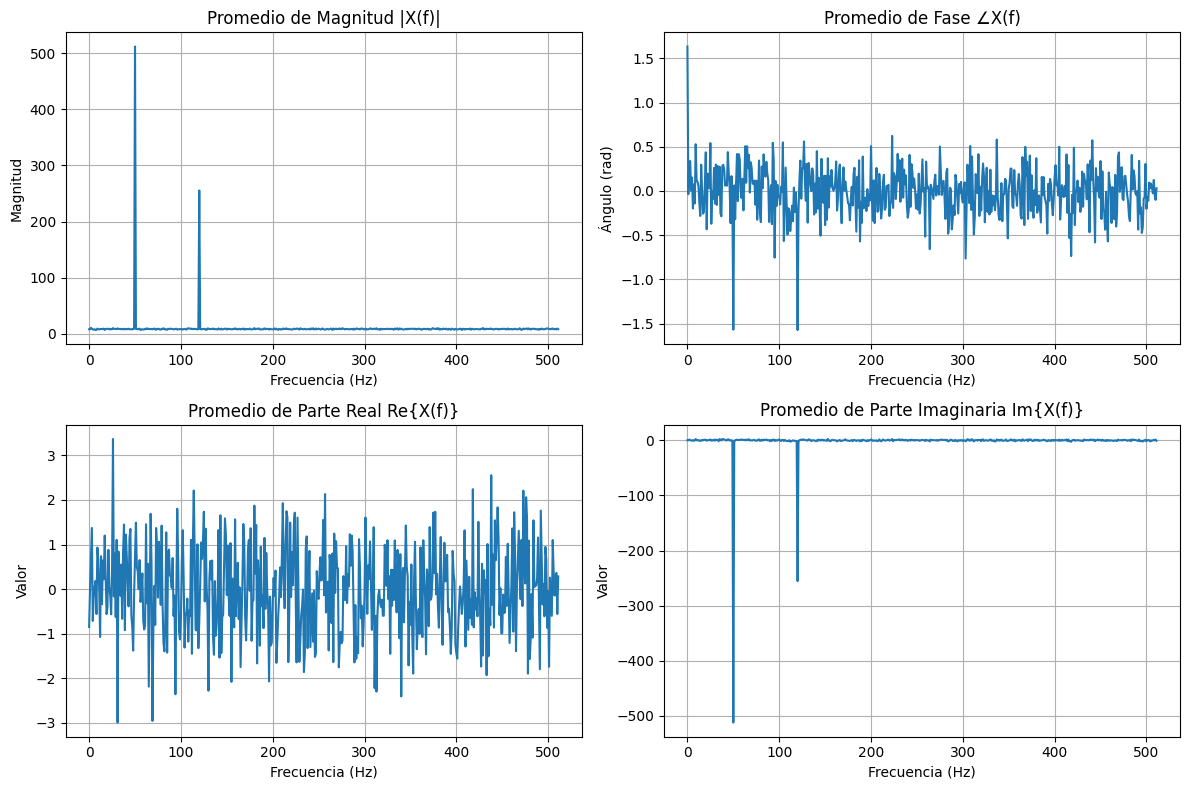

Norma promedio del espectro en 50 realizaciones: 865.6027


In [ ]:
freqs = torch.fft.fftfreq(N, d=1/fs)

plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.plot(freqs[:N//2], mean_magnitude[:N//2])
plt.title("Promedio de Magnitud |X(f)|")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Magnitud")
plt.grid()

plt.subplot(2,2,2)
plt.plot(freqs[:N//2], mean_phase[:N//2])
plt.title("Promedio de Fase ∠X(f)")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Ángulo (rad)")
plt.grid()

plt.subplot(2,2,3)
plt.plot(freqs[:N//2], mean_real[:N//2])
plt.title("Promedio de Parte Real Re{X(f)}")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Valor")
plt.grid()

plt.subplot(2,2,4)
plt.plot(freqs[:N//2], mean_imag[:N//2])
plt.title("Promedio de Parte Imaginaria Im{X(f)}")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Valor")
plt.grid()

plt.tight_layout()
plt.show()

print(f"Norma promedio del espectro en {M} realizaciones: {mean_norm:.4f}")


#🔹 Celda 6: Tren de Pulsos cuadrados con armonicos de forma adicional

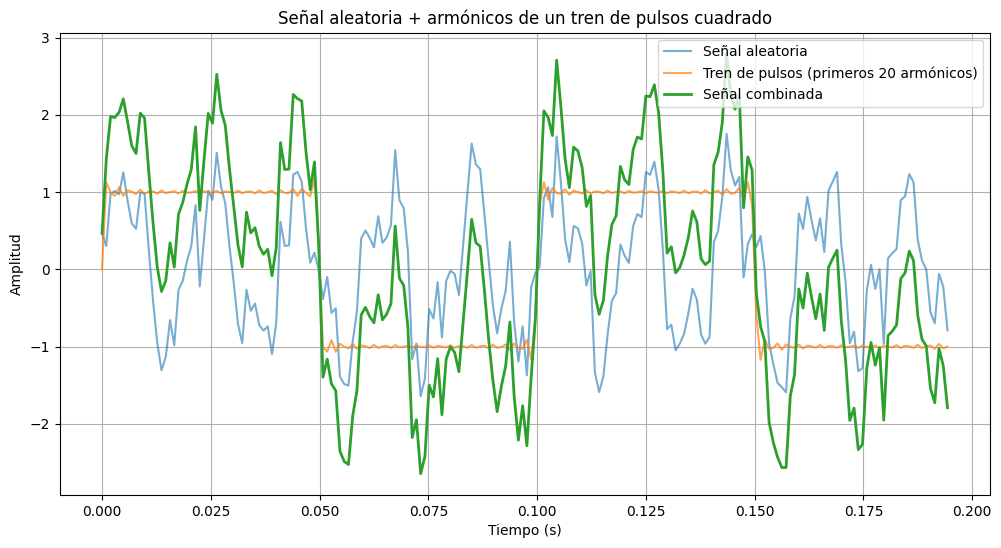

In [ ]:
import torch
import matplotlib.pyplot as plt

# Parámetros
fs = 1024        # frecuencia de muestreo
N = 1024         # número de muestras
t = torch.arange(N) / fs
f1, f2 = 50, 120  # frecuencias de la señal base
M = 1            # una realización para visualizar
f0 = 10          # frecuencia fundamental del tren de pulsos
num_harmonics = 20  # número de armónicos a sumar

# Señal aleatoria base
signal = torch.sin(2 * torch.pi * f1 * t) + 0.5*torch.sin(2 * torch.pi * f2 * t)
signal += 0.3*torch.randn(N)

# Construir tren de pulsos por Fourier (armónicos impares)
square_wave = torch.zeros_like(t)
for k in range(1, 2*num_harmonics, 2):  # solo impares
    square_wave += (1/k) * torch.sin(2 * torch.pi * k * f0 * t)

square_wave *= 4/torch.pi  # factor de escala

# Señal final = señal aleatoria + tren de pulsos
final_signal = signal + square_wave

# Graficar
plt.figure(figsize=(12,6))
plt.plot(t[:200], signal[:200], label="Señal aleatoria", alpha=0.6)
plt.plot(t[:200], square_wave[:200], label=f"Tren de pulsos (primeros {num_harmonics} armónicos)", alpha=0.7)
plt.plot(t[:200], final_signal[:200], label="Señal combinada", linewidth=2)
plt.title("Señal aleatoria + armónicos de un tren de pulsos cuadrado")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.legend()
plt.grid(True)
plt.show()


#🔹 Celda 7: Tren de Pulsos cuadrados con armonicos para una realización

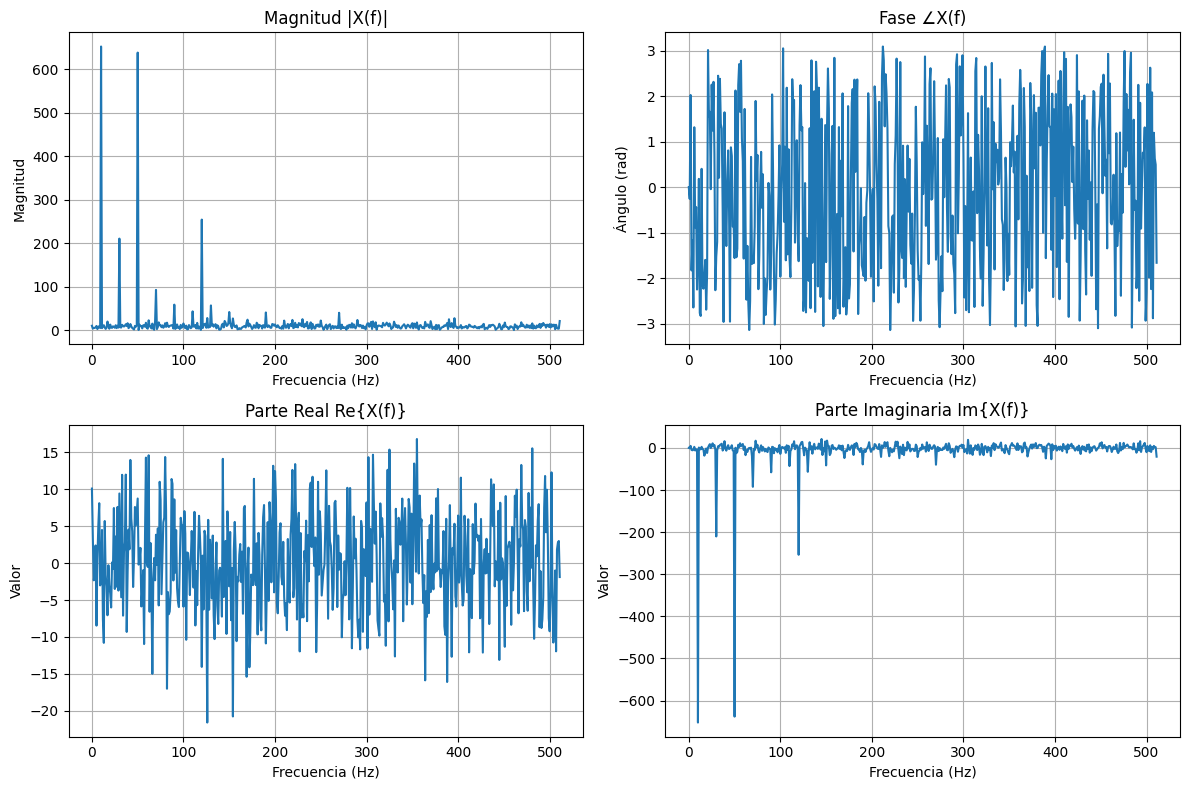

In [ ]:
import torch
import matplotlib.pyplot as plt

# Parámetros
fs = 1024        # frecuencia de muestreo
N = 1024         # número de muestras
t = torch.arange(N) / fs
f1, f2 = 50, 120  # frecuencias de la señal base
f0 = 10          # frecuencia fundamental del tren de pulsos
num_harmonics = 20  # número de armónicos

# Señal aleatoria base
signal = torch.sin(2 * torch.pi * f1 * t) + 0.5*torch.sin(2 * torch.pi * f2 * t)
signal += 0.3*torch.randn(N)

# Tren de pulsos cuadrado con los primeros armónicos impares
square_wave = torch.zeros_like(t)
for k in range(1, 2*num_harmonics, 2):  # armónicos impares
    square_wave += (1/k) * torch.sin(2 * torch.pi * k * f0 * t)
square_wave *= 4/torch.pi

# Señal final
final_signal = signal + square_wave

# FFT
fft_signal = torch.fft.fft(final_signal)

# Descriptores espectrales
magnitude = torch.abs(fft_signal)
phase = torch.angle(fft_signal)
real_part = fft_signal.real
imag_part = fft_signal.imag

# Frecuencias
freqs = torch.fft.fftfreq(N, d=1/fs)

# Graficar
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.plot(freqs[:N//2], magnitude[:N//2])
plt.title("Magnitud |X(f)|")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Magnitud")
plt.grid()

plt.subplot(2,2,2)
plt.plot(freqs[:N//2], phase[:N//2])
plt.title("Fase ∠X(f)")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Ángulo (rad)")
plt.grid()

plt.subplot(2,2,3)
plt.plot(freqs[:N//2], real_part[:N//2])
plt.title("Parte Real Re{X(f)}")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Valor")
plt.grid()

plt.subplot(2,2,4)
plt.plot(freqs[:N//2], imag_part[:N//2])
plt.title("Parte Imaginaria Im{X(f)}")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Valor")
plt.grid()

plt.tight_layout()
plt.show()


#🔹 Celda 8: Tren de Pulsos cuadrados con armonicos para multiples realizaciones

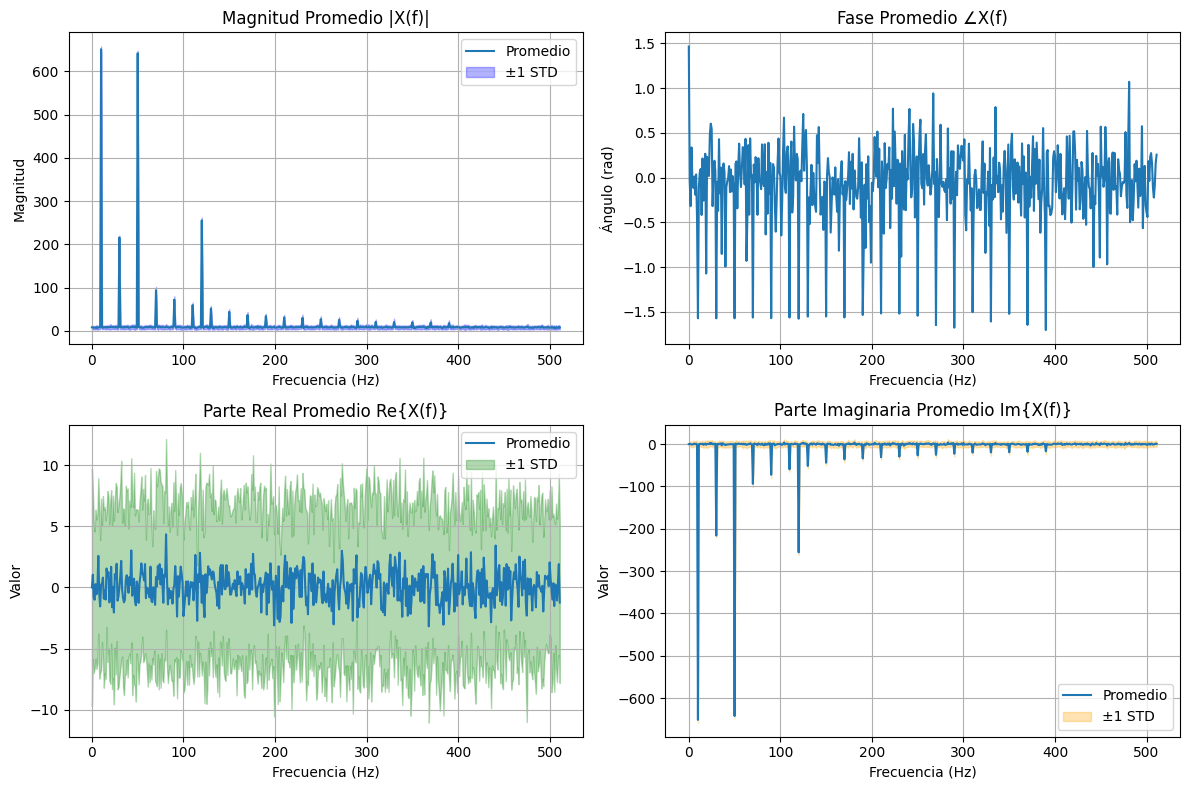

Norma promedio del espectro: 1432.4420
Desviación estándar de la norma: 6.5060


In [ ]:
import torch
import matplotlib.pyplot as plt

# Parámetros
fs = 1024        # frecuencia de muestreo
N = 1024         # número de muestras
t = torch.arange(N) / fs
f1, f2 = 50, 120  # frecuencias base
f0 = 10          # frecuencia fundamental del tren de pulsos
num_harmonics = 20  # número de armónicos
M = 30           # número de realizaciones

# Listas para almacenar resultados
magnitudes, phases, reals, imags, norms = [], [], [], [], []

for _ in range(M):
    # Señal base con ruido
    signal = torch.sin(2 * torch.pi * f1 * t) + 0.5*torch.sin(2 * torch.pi * f2 * t)
    signal += 0.3*torch.randn(N)

    # Tren de pulsos cuadrado con armónicos
    square_wave = torch.zeros_like(t)
    for k in range(1, 2*num_harmonics, 2):  # solo armónicos impares
        square_wave += (1/k) * torch.sin(2 * torch.pi * k * f0 * t)
    square_wave *= 4/torch.pi

    # Señal final
    final_signal = signal + square_wave

    # FFT
    fft_signal = torch.fft.fft(final_signal)

    # Guardar descriptores
    magnitudes.append(torch.abs(fft_signal))
    phases.append(torch.angle(fft_signal))
    reals.append(fft_signal.real)
    imags.append(fft_signal.imag)
    norms.append(torch.norm(fft_signal))

# Convertir a tensores
magnitudes = torch.stack(magnitudes)
phases = torch.stack(phases)
reals = torch.stack(reals)
imags = torch.stack(imags)
norms = torch.tensor(norms)

# Promedios
mean_magnitude = magnitudes.mean(dim=0)
mean_phase = phases.mean(dim=0)
mean_real = reals.mean(dim=0)
mean_imag = imags.mean(dim=0)
mean_norm = norms.mean()

# Desviaciones estándar
std_magnitude = magnitudes.std(dim=0)
std_phase = phases.std(dim=0)
std_real = reals.std(dim=0)
std_imag = imags.std(dim=0)
std_norm = norms.std()

# Frecuencias
freqs = torch.fft.fftfreq(N, d=1/fs)

# Graficar resultados promediados
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.plot(freqs[:N//2], mean_magnitude[:N//2], label="Promedio")
plt.fill_between(freqs[:N//2],
                 (mean_magnitude - std_magnitude)[:N//2],
                 (mean_magnitude + std_magnitude)[:N//2],
                 color="blue", alpha=0.3, label="±1 STD")
plt.title("Magnitud Promedio |X(f)|")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Magnitud")
plt.legend()
plt.grid()

plt.subplot(2,2,2)
plt.plot(freqs[:N//2], mean_phase[:N//2], label="Promedio")
plt.title("Fase Promedio ∠X(f)")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Ángulo (rad)")
plt.grid()

plt.subplot(2,2,3)
plt.plot(freqs[:N//2], mean_real[:N//2], label="Promedio")
plt.fill_between(freqs[:N//2],
                 (mean_real - std_real)[:N//2],
                 (mean_real + std_real)[:N//2],
                 color="green", alpha=0.3, label="±1 STD")
plt.title("Parte Real Promedio Re{X(f)}")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Valor")
plt.legend()
plt.grid()

plt.subplot(2,2,4)
plt.plot(freqs[:N//2], mean_imag[:N//2], label="Promedio")
plt.fill_between(freqs[:N//2],
                 (mean_imag - std_imag)[:N//2],
                 (mean_imag + std_imag)[:N//2],
                 color="orange", alpha=0.3, label="±1 STD")
plt.title("Parte Imaginaria Promedio Im{X(f)}")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Valor")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

print(f"Norma promedio del espectro: {mean_norm:.4f}")
print(f"Desviación estándar de la norma: {std_norm:.4f}")
